In [37]:
from sklearn.datasets import make_regression
import numpy as np
import matplotlib.pyplot as plt

In [38]:
X,y = make_regression(n_samples=100, n_features=1, n_informative=1, n_targets=1, noise=20)

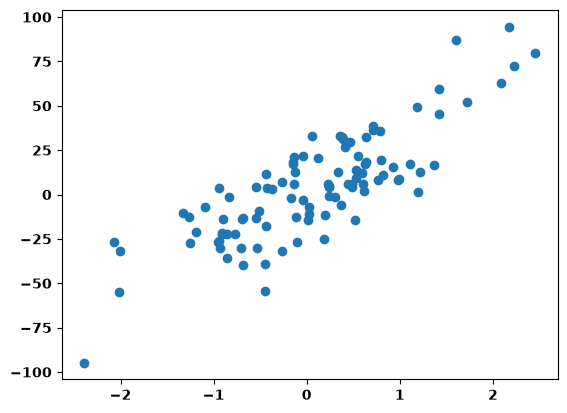

In [39]:
plt.scatter(X,y)

In [40]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

In [41]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()

In [42]:
lr.fit(X_train,y_train)
print(lr.coef_)
print(lr.intercept_)

[27.20991784]
2.9509340458922466


In [43]:
y_pred = lr.predict(X_test)
from sklearn.metrics import r2_score
r2_score(y_test, y_pred)

0.5962090768696364

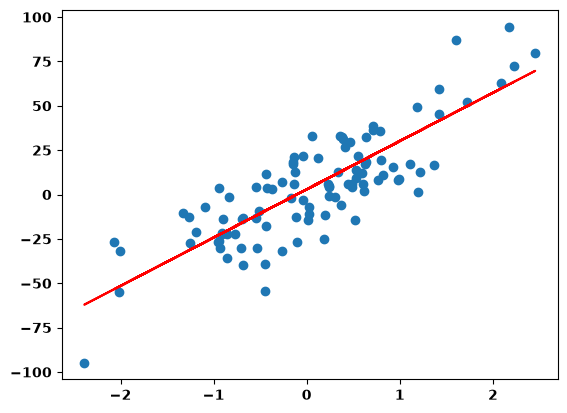

In [44]:
plt.scatter(X,y)
plt.plot(X, lr.predict(X), color='red')

In [45]:
m = lr.coef_
m

array([27.20991784])

In [ ]:
class GDRegressor: 

    def __init__(self, learning_rate,epochs):
        self.m = m
        self.b = -120
        self.lr = learning_rate
        self.epochs = epochs
    
    def fit(self,X,y):
        # calcualte the B using GD
        for i in range(self.epochs):
            loss_slope_b = -2 * np.sum(y - self.m*X.ravel() - self.b)   # formula of finding B(Intercept value)
            loss_slope_m = -2 * np.sum((y - self.m*X.ravel() - self.b)* X.ravel()) # formula of finding M(Slope value)
            self.b = self.b - (self.lr * loss_slope_b)
            self.m = self.m - (self.lr * loss_slope_m)
            
        print(self.b)
        print(self.m)

    def predict(self, X):
        return self.m * X + self.b

In [47]:
gd = GDRegressor(0.001,50)
gd.fit(X_train,y_train)

2.9298119507981206
[27.21876409]


In [48]:
y_pred2 = gd.predict(X_test)
r2_score(y_test, y_pred2)

0.5963596038344599